# Session 4, Notebook 5: 56-Agent OLG Benchmark, DEQN (Exogenous Sampling)

**Course:** Deep Learning for Solving Dynamic Models - University of Padova, 23-24 September 2026  
**Session:** Day 1, 14:25 - 15:25 - OLG models with DEQNs  
**Slides:** `04_OLG_Models_DEQNs.pdf`  
**Script reference:** §5.5 (the 56-agent Azinovic–Gaegauf–Scheidegger 2022 benchmark; two assets, borrowing/collateral constraints, persistent shocks); §5.3–§5.4 (DEQN mapping, product-form KKT)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC, University of Lausanne)  

---

This notebook solves the 56-period overlapping-generations benchmark of Azinovic, Gaegauf and Scheidegger (2022): risky illiquid capital, a risk-free one-period bond, cohort-specific borrowing and collateral constraints, lifecycle labor income, and aggregate TFP / depreciation shocks. The equilibrium conditions are the cohort-stacked capital and bond Euler equations, product-form KKT complementarity residuals for the borrowing and collateral inequalities ($\lambda_b^h\,k'^h$ and $\mu^h\,q^h$, both squared in the loss), and an explicit bond-market clearing residual.

The notebook mirrors the structure of the IRBC and analytic-OLG notebooks: parameters, augmented state, neural-network policy transform, residual / loss construction, training-data generation, mini-batch training, out-of-sample residual tables, policy-stability checks, and lifecycle plots.

In this notebook the training cloud is **drawn exogenously** from broad feasible boxes, useful for stress-testing the residual code without the additional feedback created by simulation. The complementary persistent-simulation companion (`04_02_OLG_Benchmark_DEQN_persistent.ipynb`) is the primary classroom variant and trains on the model's own ergodic set. Both expose a `RUN_MODE = "smoke" / "teaching" / "production"` switch (mirrored by the in-notebook `MODE` variable).

> **Not taught in Session 4.** The exogenous-sampling ablation of the 56-cohort benchmark. The stored run reaches a loss of 2.7e-02 on its own sampling box and 7e+11 on the simulated cloud, which is the ablation's point. Working code for this model is at <https://github.com/sischei/DeepEquilibriumNets> → `code/python-scripts/benchmark`. See `README.md` in this folder.


In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0
SAVE_FIGURES = False  # True writes the slide figures to ../../slides/figures/ (or $OLG_FIGURE_DIR)


### A note on the configuration cell below

`04_00_OLG_Diamond_Warmup.ipynb` ran the same method with every knob fixed in place.  The next two cells are where those knobs become explicit: three training budgets (`smoke`, `teaching`, `production`), the sampling switch, the loss weights, and the monitoring tolerances.  **None of it changes the model** -- the economics starts at section 1 below.


In [2]:
SAMPLING_MODE = "exogenous"

# ============================================================
# Imports, random seeds, and main switches
# ============================================================
import math
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.size"] = 12

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Training-budget switch
# ------------------------------------------------------------
# smoke      : quick code check
# teaching   : useful classroom run
# production : paper-like scale; intended for GPU/HPC runs
MODE = RUN_MODE                   # mirrors the run-mode switch in the first cell

if MODE == "smoke":
    NUM_SEGMENTS = 25
    N_TRAJECTORIES = 8
    SIMULATION_LENGTH = 16
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 5
    EVAL_TRACKS = 8
    EVAL_BURN_IN = 8
    EVAL_LENGTH = 16
    HIDDEN_UNITS = 128
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=3e-4, batch_size=128),
    ]
elif MODE == "teaching":
    # Same step size and same segments-per-learning-rate as the persistent primary 04_02, so the
    # persistent/exogenous comparison isolates the training cloud and nothing else.
    NUM_SEGMENTS = 601
    N_TRAJECTORIES = 16
    SIMULATION_LENGTH = 64
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 10
    EVAL_TRACKS = 32
    EVAL_BURN_IN = 64
    EVAL_LENGTH = 128
    HIDDEN_UNITS = 128
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=1e-4, batch_size=512),
    ]
elif MODE == "production":
    # The paper uses two hidden layers with 1000 ReLU units, 10,000 states per
    # episode, and a long two-stage learning-rate schedule.  This preset keeps
    # the same scale; it is not meant for a laptop smoke run.
    NUM_SEGMENTS = 200_000
    N_TRAJECTORIES = 1_000
    SIMULATION_LENGTH = 10
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 1_000
    EVAL_TRACKS = 64
    EVAL_BURN_IN = 512
    EVAL_LENGTH = 256
    HIDDEN_UNITS = 1_000
    TRAINING_SCHEDULE = [
        dict(until=60_000, learning_rate=1e-5, batch_size=64),
        dict(until=200_000, learning_rate=1e-6, batch_size=1_000),
    ]
else:
    raise ValueError(f"Unknown MODE: {MODE}")

STATES_PER_SEGMENT = N_TRAJECTORIES * SIMULATION_LENGTH
SHUFFLE_STATES_WITHIN_SEGMENT = True
OPTIMIZER_NAME = "Adam"
CLIP_NORM = 10.0


E0000 00:00:1788895602.289119  207387 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788895602.293981  207387 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Loss weights.  The Euler residuals are relative consumption wedges; the other
# components are scaled in the residual function below.
EULER_WEIGHT = 1.0
KKT_WEIGHT = 1.0
MARKET_WEIGHT = 1.0
PENALTY_WEIGHT = 10.0

# Monitoring on a fixed holdout cloud, as in the IRBC notebook.  The network has
# no calendar-time input, so same-state repeatability is exact; the useful check
# is whether the learned function is still moving across SGD updates.
TIME_INVARIANCE_ANCHOR_STATES = 256 if MODE == "smoke" else 2048
TIME_INVARIANCE_TOL_RMS = 1.0e-3
TIME_INVARIANCE_TOL_MAX = 1.0e-2

print(f"TensorFlow version: {tf.__version__}")
print(f"SAMPLING_MODE = {SAMPLING_MODE}")
print(f"MODE = {MODE}")
print(f"states per segment = {STATES_PER_SEGMENT}")
print(f"hidden units = {HIDDEN_UNITS}")

# ------------------------------------------------------------
# Figure export for the lecture slides (off by default)
# ------------------------------------------------------------
import os
FIGURE_DIR = os.environ.get("OLG_FIGURE_DIR", os.path.join("..", "..", "slides", "figures"))

def savefig(fig, name):
    """Write a figure for the slides when SAVE_FIGURES is on; otherwise a no-op."""
    if SAVE_FIGURES:
        os.makedirs(FIGURE_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIGURE_DIR, name), bbox_inches="tight")


TensorFlow version: 2.18.0
SAMPLING_MODE = exogenous
MODE = teaching
states per segment = 1024
hidden units = 128


## 1. Economic parameters

---

The Azinovic–Gaegauf–Scheidegger (2022) benchmark calibration: $A = 56$ overlapping agents (ages 25–80), Cobb–Douglas production, lifecycle labor profile, cohort-specific borrowing and collateral constraints, convex capital adjustment costs, and four persistent (Markov) aggregate-shock states combining TFP $\eta$ and depreciation $\delta$. The full constants are listed in the configuration block of the next code cell.


=== Benchmark OLG parameters ===
N_AGES = 56, raw state dim = 113, feature dim = 240
policy dim = 221
BETA = 0.95, GAMMA = 2.0, ALPHA = 0.3, ZETA = 0.5, KAPPA = 1.1236
Transition matrix PI:
[[0.87965995 0.09234    0.02534    0.00266   ]
 [0.09234    0.87965995 0.00266    0.02534   ]
 [0.2715     0.0285     0.6335     0.0665    ]
 [0.0285     0.2715     0.0665     0.6335    ]]
Labor: total=57.777, min=0.600, max=1.362


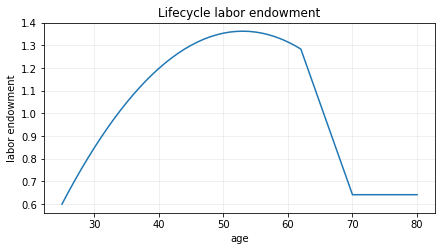

In [4]:
# ============================================================
# Benchmark OLG parameters
# ============================================================
N_AGES = 56
NUM_SHOCKS = 4
AGES = np.arange(25, 25 + N_AGES)

# Preferences and technology
BETA = 0.95
GAMMA = 2.0
ALPHA = 0.30
ZETA = 0.50
BORROWING_LIMIT_A = 0.0

# Aggregate shocks: order is
#   0 = low TFP, normal depreciation
#   1 = high TFP, normal depreciation
#   2 = low TFP, disaster depreciation
#   3 = high TFP, disaster depreciation
TFP = np.array([0.978, 1.022, 0.978, 1.022], dtype=np.float32)
DEPR = np.array([0.080, 0.080, 0.110, 0.110], dtype=np.float32)
KAPPA = 1.0 / (1.0 - float(np.max(DEPR)))

# Independent Markov chains for TFP and depreciation.
PI_DEPR = np.array([[0.972, 0.028],
                    [0.300, 0.700]], dtype=np.float32)
PI_TFP = np.array([[0.905, 0.095],
                   [0.095, 0.905]], dtype=np.float32)
PI = np.kron(PI_DEPR, PI_TFP).astype(np.float32)
PI_CUM = np.cumsum(PI, axis=1)

# Lifecycle labor endowment.  This is the smooth hump-shaped profile used in
# the notebook supplied with the course materials and is consistent with the
# benchmark description in the paper.
LABOR = np.zeros(N_AGES, dtype=np.float32)
A_IS = int(2.0 * N_AGES / 3.0)
A_DECR = int(5.0 * N_AGES / 6.0)
temp_l = 0.6 + (0.6 * 1.27 / (N_AGES / 2.0) ** 2) * ((N_AGES / 2.0) ** 2 - (A_IS - (N_AGES / 2.0)) ** 2)
for a in range(N_AGES):
    if a < A_IS:
        LABOR[a] = 0.6 + (0.6 * 1.27 / (N_AGES / 2.0) ** 2) * ((N_AGES / 2.0) ** 2 - (a - (N_AGES / 2.0)) ** 2)
    elif a < A_DECR:
        LABOR[a] = temp_l - 0.5 * temp_l * (a - A_IS) / (A_DECR - 1 - A_IS)
    else:
        LABOR[a] = 0.5 * temp_l
L_TOTAL = float(np.sum(LABOR))

# Tensor constants
TFP_TF = tf.constant(TFP.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
DEPR_TF = tf.constant(DEPR.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
PI_TF = tf.constant(PI, dtype=tf.float32)
LABOR_TF = tf.constant(LABOR.reshape(1, N_AGES), dtype=tf.float32)
L_TOTAL_TF = tf.constant(L_TOTAL, dtype=tf.float32)

RAW_STATE_DIM = 1 + 2 * N_AGES       # [z, k_1,...,k_N, b_1,...,b_N]
FEATURE_DIM = 1 + NUM_SHOCKS + 2 + 5 + 4 * N_AGES + NUM_SHOCKS
N_CHOICES = N_AGES - 1
POLICY_DIM = 4 * N_CHOICES + 1       # [a, lambda, d-raw, mu, p]

print("=== Benchmark OLG parameters ===")
print(f"N_AGES = {N_AGES}, raw state dim = {RAW_STATE_DIM}, feature dim = {FEATURE_DIM}")
print(f"policy dim = {POLICY_DIM}")
print(f"BETA = {BETA}, GAMMA = {GAMMA}, ALPHA = {ALPHA}, ZETA = {ZETA}, KAPPA = {KAPPA:.4f}")
print("Transition matrix PI:")
print(PI)
print(f"Labor: total={L_TOTAL:.3f}, min={LABOR.min():.3f}, max={LABOR.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(AGES, LABOR)
ax.set_title("Lifecycle labor endowment")
ax.set_xlabel("age")
ax.set_ylabel("labor endowment")
ax.grid(alpha=0.25)
plt.show()


## 2. State representation and augmented network inputs

---

The minimal state is $(z_t, \mathbf{k}_t, \mathbf{b}_t)$, the aggregate shock index plus the cohort capital and bond holdings, of dimension $1 + 2A = 113$. For learning, the network is fed an engineered state of dimension $240$,

$$
  \mathbf{s}_t = \bigl(z_t,\ \mathrm{onehot}(z_t),\ \eta_t,\ \delta_t,\ K_t,\ L_t,\ r_t,\ w_t,\ Y_t,\ \mathbf{k}_t,\ \mathrm{fininc}_t,\ \mathrm{labinc}_t,\ \mathrm{cash}_t,\ \boldsymbol{\pi}(z_t,\cdot)\bigr) \in \mathbb{R}^{240},
$$

where $\mathrm{fininc}_t^h = r_t k_t^h + b_t^h$ (financial income), $\mathrm{labinc}_t^h = w_t e^h$ (labor income), $\mathrm{cash}_t^h = r_t k_t^h + b_t^h + w_t e^h$, $Y_t = \eta_t K_t^\alpha L_t^{1-\alpha} + (1-\delta_t)K_t$ is the gross resource, and $\boldsymbol{\pi}(z_t,\cdot)$ is the next-period shock-transition row. The bond vector $\mathbf{b}_t$ is **recoverable** from financial income (given $r_t$ and $\mathbf{k}_t$) and is not passed as a separate block; the bond price is a network **output**, not an input. The augmentation $113 \to 240$ is feature engineering only.


In [5]:
# ============================================================
# State representation, firm prices, and network features
# ============================================================
EPS = 1.0e-8
CONSUMPTION_FLOOR = 1.0e-6

# Feature scales.  These are numerical normalizations, not equilibrium targets.
ASSET_SCALE = 1.0
AGG_K_SCALE = max(1.0, 0.5 * N_AGES)
AGG_L_SCALE = max(1.0, L_TOTAL)
PRICE_SCALE = 1.0
OUTPUT_SCALE = max(1.0, L_TOTAL)

# Broad feasible boxes for training states and initial simulation heads.  They
# are deliberately rectangular/random and do not encode a steady-state or
# lifecycle profile.
EXOGENOUS_K_LOW = 0.02
EXOGENOUS_K_HIGH = 1.25
EXOGENOUS_BOND_POS_MAX = 0.75
EXOGENOUS_BOND_NEG_FRACTION = 0.90

INITIAL_K_LOW = 0.02
INITIAL_K_HIGH = 1.25
INITIAL_BOND_POS_MAX = 0.75
INITIAL_BOND_NEG_FRACTION = 0.90

EMERGENCY_REPAIR_BAD_STATES = True
SIM_REPAIR_AGG_K_MIN = 1.0e-4
# Tie the runaway guard to the sampling box above: the widest aggregate capital the notebook is
# ever willing to call feasible is EXOGENOUS_K_HIGH per cohort.  The old value, 10 * N_AGES = 560,
# was twenty times the ergodic K, so it never fired and a diverging simulation was never caught.
SIM_REPAIR_AGG_K_MAX = EXOGENOUS_K_HIGH * N_AGES
SIM_REPAIR_ABS_B_MAX = 25.0


def unpack_state(states):
    """Return integer shock indices, capital holdings, and bond holdings."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z = tf.cast(tf.round(states[:, 0]), tf.int32)
    k = states[:, 1:1 + N_AGES]
    b = states[:, 1 + N_AGES:1 + 2 * N_AGES]
    return z, k, b


def assemble_states_tf(z, k, b):
    """Assemble a TensorFlow raw state array."""
    z = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    return tf.concat([z, tf.cast(k, tf.float32), tf.cast(b, tf.float32)], axis=1)


def assemble_states_np(z, k, b):
    """Assemble a NumPy raw state array."""
    return np.concatenate([
        np.asarray(z, dtype=np.float32).reshape(-1, 1),
        np.asarray(k, dtype=np.float32),
        np.asarray(b, dtype=np.float32),
    ], axis=1).astype(np.float32)


def firm_prices_from_components(K, eta, depr):
    """Return r, w, and aggregate output for the OLG production function."""
    K_safe = tf.maximum(tf.cast(K, tf.float32), EPS)
    L = tf.ones_like(K_safe) * L_TOTAL_TF
    eta = tf.cast(eta, tf.float32)
    depr = tf.cast(depr, tf.float32)
    r = ALPHA * eta * tf.pow(K_safe, ALPHA - 1.0) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr)
    w = (1.0 - ALPHA) * eta * tf.pow(K_safe, ALPHA) * tf.pow(L, -ALPHA)
    Y = eta * tf.pow(K_safe, ALPHA) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr) * K_safe
    return r, w, Y


def state_prices(states):
    """Prices and aggregates implied by the raw state."""
    z, k, _ = unpack_state(states)
    eta = tf.gather(TFP_TF, z)
    depr = tf.gather(DEPR_TF, z)
    K = tf.reduce_sum(k, axis=1, keepdims=True)
    r, w, Y = firm_prices_from_components(K, eta, depr)
    return K, r, w, Y, eta, depr


def current_cash_before_choices(states):
    """Cash-on-hand before current choices: r k + b + w l."""
    _, k, b = unpack_state(states)
    K, r, w, Y, eta, depr = state_prices(states)
    labor_income = w * LABOR_TF
    financial_income = r * k + b
    cash = financial_income + labor_income
    return cash, labor_income, financial_income, K, r, w, Y, eta, depr


def network_features(states):
    """Build the 240-dimensional augmented input used by the neural net.

    The raw state remains [z, k, b].  The augmentation supplies the same type of
    redundant economic information used in the paper and in the IRBC notebook:
    shock indicators, transition probabilities, prices, capital, financial
    income, labor income, and total cash-on-hand.
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z, k, _ = unpack_state(states)
    cash, labor_income, financial_income, K, r, w, Y, eta, depr = current_cash_before_choices(states)
    z_float = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    one_hot_z = tf.one_hot(z, NUM_SHOCKS, dtype=tf.float32)
    transition_row = tf.gather(PI_TF, z)
    features = tf.concat([
        z_float / max(1.0, NUM_SHOCKS - 1.0),
        one_hot_z,
        eta,
        depr,
        K / AGG_K_SCALE,
        tf.ones_like(K) * (L_TOTAL / AGG_L_SCALE),
        r / PRICE_SCALE,
        w / PRICE_SCALE,
        Y / OUTPUT_SCALE,
        k / ASSET_SCALE,
        financial_income / ASSET_SCALE,
        labor_income / ASSET_SCALE,
        cash / ASSET_SCALE,
        transition_row,
    ], axis=1)
    return features


# Quick dimension check on random raw states.
_X_dim_check = np.zeros((3, RAW_STATE_DIM), dtype=np.float32)
_X_dim_check[:, 0] = np.arange(3) % NUM_SHOCKS
_X_dim_check[:, 1:1 + N_AGES] = 0.1
_X_dim_check[:, 1] = 0.0
_X_dim_check[:, 1 + N_AGES] = 0.0
assert int(network_features(_X_dim_check).shape[1]) == FEATURE_DIM
print(f"network feature dimension check passed: {FEATURE_DIM}")


network feature dimension check passed: 240


## 3. Neural network and policy transformation

---

The policy network outputs four cohort-specific blocks plus the bond price,

$$
  \mathcal{N}_\theta(\mathbf{s}_t) \;\longrightarrow\; \bigl(\hat{k}_{t+1}^{h+1},\, \hat{\lambda}_b^{h},\, \hat{q}^h,\, \hat{\mu}^h\bigr)_{h=1}^{A-1} \;\cup\; \{\hat{p}_t\},
$$

$4(A-1) + 1 = 221$ numbers in all. The multipliers $\hat\lambda_b, \hat\mu \ge 0$ are softplus outputs and the bond price is $\beta$ times a bounded exponential. The two levels that carry inequality constraints, capital saving $\hat k'$ and the collateral slack $\hat q \equiv \hat k' + \kappa\,\hat b'$, are produced by the head selected with `CONSTRAINT_HEAD`:

- `"bounded_exp"` (default): $\hat k' = a_{\text{base}}\exp(1.5\tanh z)$ with $a_{\text{base}}$ a fifth of cash-on-hand floored at $0.02$, and $\hat q$ parameterised relative to $\hat k'$ so that $\hat q \ge e^{-2.5}\hat k'$. Zero raw output gives the baseline and $\hat b' = 0$. This head is stable at every preset. It also keeps $\hat k' \ge 0.0045$ and $\hat q > 0$ for every possible network output, so **neither constraint can bind**: the product residuals $\hat\lambda_b\hat k'$ and $\hat\mu\hat q$ of §4 are satisfied by driving the multipliers to zero, and §6 reports binding fractions of exactly zero. The KKT machinery is in place, but with this head it is not exercised.
- `"bounded_sigmoid"`: $\hat k' = a_{\text{base}}\,C\,\sigma(z + \operatorname{logit}(1/C))$ with $C = e^{1.5}$, and the same form for $\hat q$ with $C = e^{2.5}$. Same value at zero raw output, same upper cap, but the level reaches zero as the raw output falls, so the constraints can bind. At the teaching preset this head does not train: the policy collapses onto the corners of the head (most cohorts at the cap, the young at zero) within forty segments. An uncapped softplus head fails the other way, with capital and bond positions running off to infinity. Solving the benchmark with a head that can bind needs a longer schedule or a smaller learning rate than the teaching preset, and is left as the natural extension; the switch is here for that purpose.

In the Azinovic, Gaegauf and Scheidegger (2022) benchmark the young are constrained. The teaching runs in this notebook therefore show the lifecycle shapes and residual diagnostics of a slack-constraint approximation, and the binding-fraction diagnostic of §6 is the check that tells you which regime you are in.

One more thing to know before reading any number below. `marginal_utility` evaluates $u'(c) = \max(c, \texttt{CONSUMPTION\_FLOOR})^{-\gamma}$ with a floor of $10^{-6}$. Wherever the network proposes negative consumption the floor, not the model, decides what the residual says; the separate feasibility penalty is what pushes the policy back out of that region. So the `share c<=0 under policy` line in the diagnostics is not cosmetic: if it is not close to zero, the Euler residuals are being computed against a clipped utility function and should not be read as accuracy.


In [6]:
# ============================================================
# Neural network and economically admissible policy transform
# ============================================================
# The last layer is initialized at zero.  With the transformations below, zero
# raw outputs imply a dispersed, feasible, low-leverage rule: capital saving at
# its state-dependent baseline, zero bond position, p approx beta, and small
# multipliers.  This is a numerical initialization only; training states are
# not initialized at a steady state and no target policy is supplied.
#
# Two heads for the constrained levels (capital saving a, collateral slack q):
#   "bounded_exp"     : level = baseline * exp(scale * tanh(raw)), floored at MIN_CAPITAL_CHOICE.
#                       Stable at every preset.  But the level can never reach zero, so
#                       neither constraint can bind and the KKT residuals are satisfied by
#                       driving the multipliers to zero.  This is the default.
#   "bounded_sigmoid" : level = baseline * CAP * sigmoid(raw + logit(1/CAP)).  Same value at
#                       zero raw output, same upper cap, but the level reaches zero, so the
#                       constraints can bind.  At the teaching preset (200 segments, lr 2e-4)
#                       this head does not train: the policy collapses onto the corners of
#                       the head within 40 segments.  Kept as a switch for experimentation
#                       with a longer schedule or a smaller learning rate.
CONSTRAINT_HEAD = "bounded_exp"
CAPITAL_LOG_SCALE = 1.50
BOND_LOG_SCALE = 2.50
MIN_CAPITAL_CHOICE = 1.0e-5
CAPITAL_CAP = float(np.exp(CAPITAL_LOG_SCALE))
COLLATERAL_CAP = float(np.exp(BOND_LOG_SCALE))
_CAPITAL_BIAS = float(np.log(1.0 / (CAPITAL_CAP - 1.0)))
_COLLATERAL_BIAS = float(np.log(1.0 / (COLLATERAL_CAP - 1.0)))
PRICE_LOG_SCALE = 0.50
MULTIPLIER_SCALE = 0.10
MULTIPLIER_BIAS = -4.0
CAPITAL_BASE_MIN = 0.02
CAPITAL_BASE_MAX = 0.75


def build_network():
    return keras.Sequential([
        keras.layers.Input(shape=(FEATURE_DIM,)),
        keras.layers.Dense(HIDDEN_UNITS, activation="relu"),
        keras.layers.Dense(HIDDEN_UNITS, activation="relu"),
        keras.layers.Dense(
            POLICY_DIM,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
        ),
    ], name="OLG_DEQN_benchmark")


def split_raw_output(raw):
    raw_a = raw[:, 0:N_CHOICES]
    raw_lambda = raw[:, N_CHOICES:2 * N_CHOICES]
    raw_q = raw[:, 2 * N_CHOICES:3 * N_CHOICES]
    raw_mu = raw[:, 3 * N_CHOICES:4 * N_CHOICES]
    raw_p = raw[:, 4 * N_CHOICES:4 * N_CHOICES + 1]
    return raw_a, raw_lambda, raw_q, raw_mu, raw_p


def bounded_sigmoid(raw, cap, bias):
    """Head in (0, cap): equal to 1 at raw = 0, -> 0 as raw -> -inf, -> cap as raw -> +inf."""
    return cap * tf.nn.sigmoid(raw + bias)


def policy(states, model):
    """Map raw states to admissible policies.

    Returns
    -------
    a      : capital investment for ages 1,...,N-1
    lam    : KKT multipliers for the no-short-sale constraint on capital
    d      : one-period bond purchases for ages 1,...,N-1
    mu     : KKT multipliers for the collateral constraint
    p      : bond price
    coll   : collateral slack q = a + kappa d
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    raw = model(network_features(states))
    raw_a, raw_lambda, raw_q, raw_mu, raw_p = split_raw_output(raw)

    cash, _, _, _, _, _, _, _, _ = current_cash_before_choices(states)
    cash_choice = cash[:, :N_CHOICES]

    # State-dependent positive baseline: a simple feasible numerical scale, not
    # an equilibrium target.  The network learns multiplicative deviations.
    a_base = 0.20 * tf.maximum(cash_choice, 0.0) + CAPITAL_BASE_MIN
    a_base = tf.clip_by_value(a_base, CAPITAL_BASE_MIN, CAPITAL_BASE_MAX)

    if CONSTRAINT_HEAD == "bounded_exp":
        a = tf.maximum(a_base * tf.exp(CAPITAL_LOG_SCALE * tf.tanh(raw_a)), MIN_CAPITAL_CHOICE)
        # collateral slack parameterised relative to a: d >= -a/kappa, zero raw output -> d = 0
        d = -a / KAPPA + tf.maximum(a / KAPPA, EPS) * tf.exp(BOND_LOG_SCALE * tf.tanh(raw_q))
        coll = a + KAPPA * d
    elif CONSTRAINT_HEAD == "bounded_sigmoid":
        a = a_base * bounded_sigmoid(raw_a, CAPITAL_CAP, _CAPITAL_BIAS)
        coll = a_base * bounded_sigmoid(raw_q, COLLATERAL_CAP, _COLLATERAL_BIAS)
        d = (coll - a) / KAPPA
    else:
        raise ValueError(f"Unknown CONSTRAINT_HEAD: {CONSTRAINT_HEAD}")

    lam = MULTIPLIER_SCALE * tf.nn.softplus(raw_lambda + MULTIPLIER_BIAS)
    mu = MULTIPLIER_SCALE * tf.nn.softplus(raw_mu + MULTIPLIER_BIAS)
    p = BETA * tf.exp(PRICE_LOG_SCALE * tf.tanh(raw_p))
    return a, lam, d, mu, p, coll


def policy_fingerprint(states, model):
    """Dimensionless policy vector for policy-drift diagnostics."""
    a, lam, d, mu, p, _ = policy(states, model)
    return tf.concat([
        tf.math.log1p(a),
        d / (1.0 + tf.abs(d)),
        tf.math.log(tf.maximum(lam, EPS)),
        tf.math.log(tf.maximum(mu, EPS)),
        tf.math.log(tf.maximum(p, EPS) / BETA),
    ], axis=1)


def relative_policy_drift(previous, current):
    previous = np.asarray(previous, dtype=np.float64)
    current = np.asarray(current, dtype=np.float64)
    diff = current - previous
    scale = 1.0 + np.sqrt(np.mean(previous ** 2))
    return float(np.sqrt(np.mean(diff ** 2)) / scale), float(np.max(np.abs(diff)) / scale)


model_check = build_network()
a0, lam0, d0, mu0, p0, coll0 = policy(_X_dim_check, model_check)
print("Initial-policy smoke check")
print(f"  mean a      = {float(tf.reduce_mean(a0)):.4f}")
print(f"  mean d      = {float(tf.reduce_mean(d0)):.4e}")
print(f"  mean p      = {float(tf.reduce_mean(p0)):.4f}")
print(f"  min coll    = {float(tf.reduce_min(coll0)):.4e}")


Initial-policy smoke check
  mean a      = 0.1395
  mean d      = 0.0000e+00
  mean p      = 0.9500
  min coll    = 6.0570e-02


## 4. Residuals and loss

---

For each cohort $h = 1, \ldots, A-1$ there are a capital Euler equation, a bond Euler equation and two complementarity conditions. Write $\mathcal{A}_t^h = 1 + \zeta\,(k_{t+1}^{h+1} - r_t k_t^h)$ for the marginal adjustment-cost wedge and $r_{t+1} = \alpha\,\eta_{t+1} K_{t+1}^{\alpha-1} L^{1-\alpha} + 1 - \delta_{t+1}$ for the gross return on capital. The capital Euler equation is

$$
  u'(c_t^h)\,\mathcal{A}_t^h \;=\; \beta\,\mathbb{E}_t\!\left[\, r_{t+1}\,\mathcal{A}_{t+1}^{h+1}\, u'(c_{t+1}^{h+1})\,\right] + \lambda_b^h + \mu^h ,
$$

where the wedge reappears on the return side because next period's adjustment cost $\tfrac{\zeta}{2}(k_{t+2}^{h+2} - r_{t+1}k_{t+1}^{h+1})^2$ depends on this period's choice (its derivative with respect to $k_{t+1}^{h+1}$ is $-r_{t+1}\zeta(\cdot)$, so the marginal return is $r_{t+1}\mathcal{A}_{t+1}^{h+1}$). Its *relative* residual inverts marginal utility on the right-hand side and divides by the consumption the network actually chose,

$$
  \mathrm{EulerErr}_h^{(k)}(\mathbf{s}_t) \;=\;
  \frac{(u')^{-1}\!\Bigl(\bigl[\beta\,\mathbb{E}_t[\, r_{t+1}\mathcal{A}_{t+1}^{h+1}u'(c_{t+1}^{h+1})\,] + \lambda_b^h + \mu^h\bigr]\big/\mathcal{A}_t^h\Bigr)}{c_t^h} \;-\; 1 ,
$$

so a value of $10^{-3}$ is a 0.1% consumption wedge. The bond Euler equation $u'(c_t^h)\,p_t = \beta\,\mathbb{E}_t[u'(c_{t+1}^{h+1})] + \kappa\,\mu^h$ gives the analogous residual with $p_t$ in the denominator; when the collateral constraint is slack this is the textbook $p_t = \mathbb{E}_t[\text{SDF}]$, and a binding constraint adds the shadow value $\kappa\mu^h/u'(c_t^h)$ to the price the constrained cohort is willing to pay. The complementarity conditions enter as the *squared product residuals*

$$
  \mathrm{KKT}_{\mathrm{borrow}}^h \;=\; \lambda_b^h \cdot k_{t+1}^{h+1}, \qquad
  \mathrm{KKT}_{\mathrm{coll}}^h \;=\; \mu^h \cdot q^h ;
$$

both factors are non-negative by construction of the heads in §3, so each product vanishes exactly at a KKT point. (The Fischer–Burmeister alternative $\Phi(a,b) = a + b - \sqrt{a^2 + b^2}$ is used in the IRBC notebook, where the irreversibility constraint binds on a larger share of states.) Bond-market clearing is an explicit residual, $\sum_{h=1}^{A-1} b_{t+1}^{h+1} = 0$, scaled by $1 + \sum_h |b_{t+1}^{h+1}|$ so that it is dimensionless. The conditional expectations are exact four-term sums over next period's shock, weighted by the persistent transition row $\pi(z_t,\cdot)$.

The loss is a weighted sum of the four block means (`EULER_WEIGHT`, `KKT_WEIGHT`, `MARKET_WEIGHT`, all equal to one) plus the feasibility penalties (`PENALTY_WEIGHT` $= 10$). Relative to the uniform "$1/221$" formula on the slides this only re-weights blocks; the zeros are the same.


In [7]:
# ============================================================
# Residuals and loss
# ============================================================

def marginal_utility(c):
    return tf.pow(tf.maximum(c, CONSUMPTION_FLOOR), -GAMMA)


def inverse_marginal_utility(x):
    return tf.pow(tf.maximum(x, CONSUMPTION_FLOOR), -1.0 / GAMMA)


def consumption_and_adjustment(states, a, d, p):
    """Budget constraint for all ages, including a_N=d_N=0."""
    _, k, b = unpack_state(states)
    cash, labor_income, financial_income, K, r, w, Y, eta, depr = current_cash_before_choices(states)
    a_all = tf.concat([a, tf.zeros([tf.shape(states)[0], 1], dtype=tf.float32)], axis=1)
    d_all = tf.concat([d, tf.zeros([tf.shape(states)[0], 1], dtype=tf.float32)], axis=1)
    adjustment = a_all - r * k
    adjustment_cost = 0.5 * ZETA * tf.square(adjustment)
    c_raw = cash - a_all - p * d_all - adjustment_cost
    return c_raw, adjustment, K, r, w, Y


@tf.function
def compute_residuals(states, model):
    """Return the DEQN loss and residual components on a state batch."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    m = tf.shape(states)[0]
    z, _, _ = unpack_state(states)
    probs_next = tf.gather(PI_TF, z)

    # Code name -> slide symbol:  a = k'^h (capital),  d = b'^h (bonds),  coll = q^h = k'^h + kappa b'^h,
    # lam = lambda_b^h (borrowing multiplier),  mu = mu^h (collateral multiplier),  p = p_t (bond price).
    a, lam, d, mu, p, coll = policy(states, model)
    c_raw, adjustment, K, r, w, Y = consumption_and_adjustment(states, a, d, p)
    c = tf.maximum(c_raw, CONSUMPTION_FLOOR)

    # Age everyone by one period: today's savings a^h become tomorrow's k^{h+1}, and the
    # newborn enters with k^1 = 0.  Summing k_next is capital-market clearing by construction.
    k_next = tf.concat([tf.zeros([m, 1], dtype=tf.float32), a], axis=1)
    b_next = tf.concat([tf.zeros([m, 1], dtype=tf.float32), d], axis=1)

    expected_capital = tf.zeros([m, N_CHOICES], dtype=tf.float32)
    expected_bond = tf.zeros([m, N_CHOICES], dtype=tf.float32)
    future_c_raw = []
    future_adj_factors = []

    for shock in range(NUM_SHOCKS):
        z_next = tf.ones([m], dtype=tf.float32) * float(shock)
        x_next = assemble_states_tf(z_next, k_next, b_next)
        # THE Deep Equilibrium Net step: the network evaluated at its own successor state,
        # once per possible shock.  Tomorrow's consumption for cohort h+1 is whatever this
        # same network decides there, so the loss is a fixed-point condition on theta.
        a_next, _, d_next, _, p_next, _ = policy(x_next, model)
        c_next_raw, adjustment_next, _, r_next, _, _ = consumption_and_adjustment(x_next, a_next, d_next, p_next)
        c_next = tf.maximum(c_next_raw, CONSUMPTION_FLOOR)

        prob = probs_next[:, shock:shock + 1]
        future_marginal = marginal_utility(c_next[:, 1:N_AGES])
        adj_factor_next = 1.0 + ZETA * adjustment_next[:, 1:N_AGES]
        expected_capital += prob * r_next * adj_factor_next * future_marginal
        expected_bond += prob * future_marginal
        future_c_raw.append(c_next_raw)
        future_adj_factors.append(adj_factor_next)

    adj_factor_now = 1.0 + ZETA * adjustment[:, 0:N_CHOICES]
    adj_factor_now_safe = tf.maximum(adj_factor_now, CONSUMPTION_FLOOR)

    # Capital Euler equation, u'(c)A = beta E[u'(c')r'A'] + lambda_b + mu, solved for the
    # consumption it implies.  Both multipliers enter with coefficient 1 because both
    # constraints, k' >= 0 and k' + kappa b' >= 0, have derivative 1 in k'.
    euler_cap_arg = (BETA * expected_capital + lam + mu) / adj_factor_now_safe
    euler_capital = inverse_marginal_utility(euler_cap_arg) / c[:, 0:N_CHOICES] - 1.0

    # Bond Euler equation, u'(c)p = beta E[u'(c')] + kappa mu.  Only the collateral constraint
    # involves b', and its derivative there is kappa, which is why mu is scaled by kappa here
    # and lambda_b does not appear at all.
    euler_bond_arg = (BETA * expected_bond + KAPPA * mu) / tf.maximum(p, CONSUMPTION_FLOOR)
    euler_bond = inverse_marginal_utility(euler_bond_arg) / c[:, 0:N_CHOICES] - 1.0

    kkt_capital = lam * a
    kkt_bond = mu * coll

    bond_market_raw = tf.reduce_sum(d, axis=1, keepdims=True)
    # Two different objects, and the diagnostics report both: bond_market_raw is the level
    # sum_h b'^h that should be zero, bond_market_scaled is the dimensionless version that
    # actually enters the loss.  Judge convergence on the raw one.
    bond_market_scaled = bond_market_raw / (1.0 + tf.reduce_sum(tf.abs(d), axis=1, keepdims=True))
    bond_market_normalized = bond_market_raw / tf.maximum(Y, CONSUMPTION_FLOOR)

    all_c_raw = tf.concat([c_raw] + future_c_raw, axis=1)
    neg_c_penalty = tf.maximum(-all_c_raw, 0.0) / (1.0 + tf.abs(all_c_raw))

    all_adj_factors = tf.concat([adj_factor_now] + future_adj_factors, axis=1)
    bad_adj_penalty = tf.maximum(-all_adj_factors, 0.0) / (1.0 + tf.abs(all_adj_factors))

    loss = (
        EULER_WEIGHT * (tf.reduce_mean(tf.square(euler_capital)) + tf.reduce_mean(tf.square(euler_bond)))
        + KKT_WEIGHT * (tf.reduce_mean(tf.square(kkt_capital)) + tf.reduce_mean(tf.square(kkt_bond)))
        + MARKET_WEIGHT * tf.reduce_mean(tf.square(bond_market_scaled))
        + PENALTY_WEIGHT * (tf.reduce_mean(tf.square(neg_c_penalty)) + tf.reduce_mean(tf.square(bad_adj_penalty)))
    )

    components = {
        "euler_capital": euler_capital,
        "euler_bond": euler_bond,
        "kkt_capital": kkt_capital,
        "kkt_bond": kkt_bond,
        "bond_market_raw": bond_market_raw,
        "bond_market_scaled": bond_market_scaled,
        "bond_market_normalized": bond_market_normalized,
        "c_raw": c_raw,
        "c": c,
        "a": a,
        "d": d,
        "p": p,
        "lambda": lam,
        "mu": mu,
        "collateral_slack": coll,
        "K": K,
        "Y": Y,
        "negative_consumption_penalty": neg_c_penalty,
        "bad_adjustment_penalty": bad_adj_penalty,
    }
    return loss, components


_loss_check, _comp_check = compute_residuals(_X_dim_check, model_check)
print(f"initial residual finite: {np.isfinite(float(_loss_check.numpy()))}, loss = {float(_loss_check.numpy()):.3e}")


initial residual finite: True, loss = 8.379e-02


## 4b. Training-data construction

In this version, training states are drawn exogenously from broad feasible boxes. This is useful for checking the residual code without the additional feedback created by simulation. The state clouds are deliberately not centered on a deterministic steady state.


In [8]:
# ============================================================
# Training-data construction
# ============================================================

def _sample_feasible_box(n, k_low, k_high, bond_pos_max, bond_neg_fraction, local_rng):
    """Random feasible states from broad boxes; no lifecycle or steady-state prior."""
    z = local_rng.integers(0, NUM_SHOCKS, size=n).astype(np.float32)
    log_k = local_rng.uniform(np.log(k_low), np.log(k_high), size=(n, N_AGES)).astype(np.float32)
    k = np.exp(log_k).astype(np.float32)
    k[:, 0] = 0.0

    b_low = -bond_neg_fraction * k / KAPPA
    b_high = bond_pos_max * np.ones_like(k, dtype=np.float32)
    b = local_rng.uniform(b_low, b_high).astype(np.float32)
    b[:, 0] = 0.0
    return assemble_states_np(z, k, b)


def sample_exogenous_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 1000 + seed_offset)
    return _sample_feasible_box(
        n,
        EXOGENOUS_K_LOW,
        EXOGENOUS_K_HIGH,
        EXOGENOUS_BOND_POS_MAX,
        EXOGENOUS_BOND_NEG_FRACTION,
        local_rng,
    )


def sample_feasible_initial_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 2000 + seed_offset)
    return _sample_feasible_box(
        n,
        INITIAL_K_LOW,
        INITIAL_K_HIGH,
        INITIAL_BOND_POS_MAX,
        INITIAL_BOND_NEG_FRACTION,
        local_rng,
    )


def draw_next_shocks(z_current):
    z_int = np.asarray(np.round(z_current), dtype=np.int64)
    u = rng.random(len(z_int))
    return np.sum(u[:, None] > PI_CUM[z_int], axis=1).astype(np.float32)


def one_step_transition(states_np, model, z_next_np):
    states_tf = tf.constant(states_np, dtype=tf.float32)
    a, _, d, _, _, _ = policy(states_tf, model)
    a_np = a.numpy().astype(np.float32)
    d_np = d.numpy().astype(np.float32)
    k_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), a_np], axis=1)
    b_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), d_np], axis=1)
    return assemble_states_np(z_next_np, k_next, b_next)


def bad_state_mask(states_np):
    states_np = np.asarray(states_np, dtype=np.float32)
    finite = np.all(np.isfinite(states_np), axis=1)
    z = states_np[:, 0]
    k = states_np[:, 1:1 + N_AGES]
    b = states_np[:, 1 + N_AGES:1 + 2 * N_AGES]
    K = np.sum(k, axis=1)
    collateral_ok = np.all(b >= -k / KAPPA - 1.0e-5, axis=1)
    mask_good = (
        finite
        & (z >= -0.5) & (z <= NUM_SHOCKS - 0.5)
        & np.all(k >= -1.0e-7, axis=1)
        & collateral_ok
        & (K >= SIM_REPAIR_AGG_K_MIN)
        & (K <= SIM_REPAIR_AGG_K_MAX)
        & np.all(np.abs(b) <= SIM_REPAIR_ABS_B_MAX, axis=1)
    )
    return ~mask_good


def simulate_path(X0, model, n_steps, seed_offset=0, return_time_major=False):
    """Simulate under the current learned policy.

    The initial states are supplied by sample_feasible_initial_states, not by a
    steady-state calculation.  Emergency repair only replaces numerically invalid
    states by fresh feasible-box draws.
    """
    X = np.asarray(X0, dtype=np.float32).copy()
    n_tracks = X.shape[0]
    path = np.empty((n_steps, n_tracks, RAW_STATE_DIM), dtype=np.float32)
    n_repaired = 0

    for t in range(n_steps):
        path[t] = X
        z_next = draw_next_shocks(X[:, 0])
        X_next = one_step_transition(X, model, z_next)
        if EMERGENCY_REPAIR_BAD_STATES:
            bad = bad_state_mask(X_next)
            if np.any(bad):
                n_bad = int(np.sum(bad))
                X_next[bad] = sample_feasible_initial_states(n_bad, seed_offset=seed_offset + 10_000 + t)
                n_repaired += n_bad
        X = X_next

    if return_time_major:
        return path, X, n_repaired
    return path.reshape(-1, RAW_STATE_DIM), X, n_repaired


def get_training_segment(X_start, model, segment_index):
    if SAMPLING_MODE == "exogenous":
        X = sample_exogenous_states(STATES_PER_SEGMENT, seed_offset=segment_index)
        return X, X_start, 0
    if SAMPLING_MODE == "simulation":
        return simulate_path(X_start, model, SIMULATION_LENGTH, seed_offset=segment_index)
    raise ValueError(f"Unknown SAMPLING_MODE: {SAMPLING_MODE}")


def sample_time_invariance_anchor_states(n):
    return sample_exogenous_states(n, seed_offset=999_001)


X_sampling_check = sample_exogenous_states(5)
print("sample state shape:", X_sampling_check.shape)
print("bad sampled states:", int(np.sum(bad_state_mask(X_sampling_check))))


sample state shape: (5, 113)
bad sampled states: 0


## 5. Mini-batches and training loop

---

A training segment may contain many states.  `TRAINING_SCHEDULE` supplies the learning rate and the mini-batch size for each segment, and `PASSES_PER_SEGMENT` and `OPTIMIZER_NAME` decide how the optimizer then sweeps those states.  The segment-continuation logic is intentionally explicit:

```python
learning_rate, batch_size = hyperparameters_for_segment(segment)
X_segment, X_end, n_repaired = get_training_segment(X_start, model, segment)
... optimizer updates on X_segment, in mini-batches of batch_size ...
X_start = X_end          # the next segment continues where this one ended
```

`n_repaired` counts states that left the feasible region during the simulation and were resampled (`EMERGENCY_REPAIR_BAD_STATES`); on a healthy run it stays at zero, and the monitor prints it every line so that a policy drifting out of the ergodic set is visible immediately.


In [9]:
# ============================================================
# Mini-batches, optimizer, and training loop
# ============================================================

def make_optimizer(learning_rate):
    if OPTIMIZER_NAME == "Adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "RMSprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "SGD":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0)
    raise ValueError(f"Unknown optimizer: {OPTIMIZER_NAME}")


def hyperparameters_for_segment(segment):
    for item in TRAINING_SCHEDULE:
        if segment < int(item["until"]):
            return float(item["learning_rate"]), int(item["batch_size"])
    item = TRAINING_SCHEDULE[-1]
    return float(item["learning_rate"]), int(item["batch_size"])


def set_optimizer_learning_rate(optimizer, learning_rate):
    try:
        optimizer.learning_rate.assign(learning_rate)
    except Exception:
        optimizer.learning_rate = learning_rate


def iterate_minibatches(X, batch_size):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    if SHUFFLE_STATES_WITHIN_SEGMENT:
        order = rng.permutation(n)
    else:
        order = np.arange(n)
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        if len(idx) > 0:
            yield tf.constant(X[idx], dtype=tf.float32)


@tf.function
def train_step(X_batch, model, optimizer):
    with tf.GradientTape() as tape:
        loss, _ = compute_residuals(X_batch, model)
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, model.trainable_variables)]
    if CLIP_NORM is not None:
        grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train_on_segment_states(X_segment, model, optimizer, batch_size):
    losses = []
    for _ in range(PASSES_PER_SEGMENT):
        for X_batch in iterate_minibatches(X_segment, batch_size):
            losses.append(float(train_step(X_batch, model, optimizer).numpy()))
    return float(np.mean(losses)), len(losses)


def summarize_monitor_components(components):
    return {
        "mean_abs_euler_capital": float(tf.reduce_mean(tf.abs(components["euler_capital"])).numpy()),
        "mean_abs_euler_bond": float(tf.reduce_mean(tf.abs(components["euler_bond"])).numpy()),
        "mean_abs_kkt_capital": float(tf.reduce_mean(tf.abs(components["kkt_capital"])).numpy()),
        "mean_abs_kkt_bond": float(tf.reduce_mean(tf.abs(components["kkt_bond"])).numpy()),
        "mean_abs_bond_market": float(tf.reduce_mean(tf.abs(components["bond_market_raw"])).numpy()),
        "share_negative_consumption": float(tf.reduce_mean(tf.cast(components["c_raw"] <= 0.0, tf.float32)).numpy()),
    }


model = build_network()
learning_rate_0, _batch_size_0 = hyperparameters_for_segment(0)
optimizer = make_optimizer(learning_rate_0)

X_start = sample_feasible_initial_states(N_TRAJECTORIES)
X_anchor = sample_time_invariance_anchor_states(TIME_INVARIANCE_ANCHOR_STATES)
anchor_fingerprint_previous = policy_fingerprint(tf.constant(X_anchor), model).numpy()

history = {
    "segment": [],
    "loss": [],
    "train_loss": [],
    "mean_abs_euler_capital": [],
    "mean_abs_euler_bond": [],
    "mean_abs_kkt_capital": [],
    "mean_abs_kkt_bond": [],
    "mean_abs_bond_market": [],
    "share_negative_consumption": [],
    "policy_drift_rms": [],
    "policy_drift_max": [],
    "K_min": [],
    "K_max": [],
    "repairs": [],
    "n_updates": [],
}

print("Starting training")
print(f"  segments: {NUM_SEGMENTS}")
print(f"  states per segment: {STATES_PER_SEGMENT}")
print(f"  passes per segment: {PASSES_PER_SEGMENT}")
start_time = time.time()
last_segment = None

for segment in range(NUM_SEGMENTS):
    learning_rate, batch_size = hyperparameters_for_segment(segment)
    set_optimizer_learning_rate(optimizer, learning_rate)

    X_segment, X_end, n_repaired = get_training_segment(X_start, model, segment)
    train_loss, n_updates = train_on_segment_states(X_segment, model, optimizer, batch_size)
    last_segment = X_segment

    if SAMPLING_MODE == "simulation":
        X_start = X_end

    if segment % MONITOR_EVERY == 0 or segment == NUM_SEGMENTS - 1:
        loss_now, components_now = compute_residuals(tf.constant(X_segment), model)
        monitor = summarize_monitor_components(components_now)
        K_np = X_segment[:, 1:1 + N_AGES].sum(axis=1)
        anchor_fingerprint_current = policy_fingerprint(tf.constant(X_anchor), model).numpy()
        drift_rms, drift_max = relative_policy_drift(anchor_fingerprint_previous, anchor_fingerprint_current)
        anchor_fingerprint_previous = anchor_fingerprint_current

        history["segment"].append(segment)
        history["loss"].append(float(loss_now.numpy()))
        history["train_loss"].append(train_loss)
        for key, value in monitor.items():
            history[key].append(value)
        history["policy_drift_rms"].append(drift_rms)
        history["policy_drift_max"].append(drift_max)
        history["K_min"].append(float(np.min(K_np)))
        history["K_max"].append(float(np.max(K_np)))
        history["repairs"].append(int(n_repaired))
        history["n_updates"].append(int(n_updates))

        elapsed = time.time() - start_time
        print(
            f"seg {segment:6d} | log10(loss)={np.log10(max(history['loss'][-1], 1e-30)): .3f} | "
            f"Euler K={monitor['mean_abs_euler_capital']:.3e}, Euler B={monitor['mean_abs_euler_bond']:.3e} | "
            f"K=[{history['K_min'][-1]:.3f},{history['K_max'][-1]:.3f}] | "
            f"drift={drift_rms:.2e} | repairs={n_repaired} | {elapsed:.1f}s"
        )

print(f"Training finished in {time.time() - start_time:.1f} seconds")


Starting training
  segments: 601
  states per segment: 1024
  passes per segment: 1


seg      0 | log10(loss)=-0.680 | Euler K=3.413e-01, Euler B=2.180e-01 | K=[9.237,24.096] | drift=3.95e-04 | repairs=0 | 7.2s


seg     10 | log10(loss)=-0.826 | Euler K=2.738e-01, Euler B=1.846e-01 | K=[8.092,23.931] | drift=8.10e-03 | repairs=0 | 7.7s


seg     20 | log10(loss)=-0.959 | Euler K=1.864e-01, Euler B=1.812e-01 | K=[9.161,24.818] | drift=1.82e-02 | repairs=0 | 8.3s


seg     30 | log10(loss)=-1.003 | Euler K=1.882e-01, Euler B=1.685e-01 | K=[9.838,25.778] | drift=1.02e-02 | repairs=0 | 8.8s


...

seg    560 | log10(loss)=-1.561 | Euler K=9.192e-02, Euler B=8.778e-02 | K=[9.494,24.814] | drift=1.54e-03 | repairs=0 | 38.9s


seg    570 | log10(loss)=-1.556 | Euler K=9.239e-02, Euler B=8.828e-02 | K=[9.636,23.886] | drift=1.71e-03 | repairs=0 | 39.5s


seg    580 | log10(loss)=-1.567 | Euler K=9.073e-02, Euler B=8.721e-02 | K=[9.555,23.333] | drift=1.33e-03 | repairs=0 | 40.1s


seg    590 | log10(loss)=-1.564 | Euler K=9.109e-02, Euler B=8.728e-02 | K=[8.421,24.115] | drift=2.16e-03 | repairs=0 | 40.7s


seg    600 | log10(loss)=-1.570 | Euler K=9.053e-02, Euler B=8.634e-02 | K=[9.953,23.472] | drift=2.56e-03 | repairs=0 | 41.3s
Training finished in 41.3 seconds


## 6. Final diagnostics

---

The final diagnostics report relative Euler residuals on two out-of-sample state clouds, an exogenous test cloud for off-trajectory robustness, and a simulated test cloud for accuracy on the ergodic region induced by the learned policy. Mean and max absolute Euler residuals are dimensionless, so a *mean* of, say, $2 \times 10^{-3}$ corresponds to a 0.2% average wedge.


In [10]:
# ============================================================
# Final diagnostics: residual tables and data-cloud checks
# ============================================================

def _np_abs(x):
    return np.abs(np.asarray(x, dtype=np.float64).reshape(-1))


def stats_row(values, scale=1.0):
    v = scale * _np_abs(values)
    return {
        "mean": float(np.mean(v)),
        "max": float(np.max(v)),
        "p0.1": float(np.quantile(v, 0.001)),
        "p10": float(np.quantile(v, 0.10)),
        "p50": float(np.quantile(v, 0.50)),
        "p90": float(np.quantile(v, 0.90)),
        "p99.9": float(np.quantile(v, 0.999)),
    }


def residual_table(X, model):
    loss, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    rows = {
        "Rel Ee capital [%]": stats_row(comp["euler_capital"].numpy(), scale=100.0),
        "Rel Ee bond [%]": stats_row(comp["euler_bond"].numpy(), scale=100.0),
        "KKT capital": stats_row(comp["kkt_capital"].numpy()),
        "KKT bond": stats_row(comp["kkt_bond"].numpy()),
        "Market clearing": stats_row(comp["bond_market_raw"].numpy()),
        "Market clearing / Y": stats_row(comp["bond_market_normalized"].numpy()),
    }
    table = pd.DataFrame(rows).T[["mean", "max", "p0.1", "p10", "p50", "p90", "p99.9"]]
    return float(loss.numpy()), table, comp


def data_cloud_report(label, X, model):
    X = np.asarray(X, dtype=np.float32)
    z = X[:, 0].astype(int)
    k = X[:, 1:1 + N_AGES]
    b = X[:, 1 + N_AGES:1 + 2 * N_AGES]
    loss, comp = compute_residuals(tf.constant(X), model)
    c_raw = comp["c_raw"].numpy()
    coll_state_violation = np.min(b + k / KAPPA)
    print(f"\n{label}")
    print(f"  states                         {X.shape[0]}")
    print(f"  shock counts                   {np.bincount(z, minlength=NUM_SHOCKS)}")
    print(f"  aggregate K range              [{k.sum(axis=1).min():.4f}, {k.sum(axis=1).max():.4f}]")
    print(f"  bond range                     [{b.min():.4f}, {b.max():.4f}]")
    print(f"  min state collateral slack      {coll_state_violation:.4e}")
    print(f"  consumption range under policy  [{c_raw.min():.4e}, {c_raw.max():.4e}]")
    print(f"  share c<=0 under policy         {np.mean(c_raw <= 0.0):.4%}")
    print(f"  loss                            {float(loss.numpy()):.3e}")


def simulated_evaluation_states(model, n_eval_tracks=EVAL_TRACKS, burn_in=EVAL_BURN_IN, eval_length=EVAL_LENGTH):
    X0 = sample_feasible_initial_states(n_eval_tracks, seed_offset=777)
    path, _, n_repaired = simulate_path(X0, model, burn_in + eval_length, seed_offset=888, return_time_major=True)
    if n_repaired > 0:
        print(f"evaluation simulation repaired {n_repaired} numerically invalid states")
    path_eval = path[burn_in:]
    return path_eval.reshape(-1, RAW_STATE_DIM)


N_EVAL_EXOGENOUS = 1024 if MODE == "smoke" else 8192
X_eval_exog = sample_exogenous_states(N_EVAL_EXOGENOUS, seed_offset=54321)
X_eval_sim = simulated_evaluation_states(model)

if last_segment is not None:
    data_cloud_report("Last training segment", last_segment, model)
data_cloud_report("Out-of-sample exogenous state cloud", X_eval_exog, model)
data_cloud_report("Out-of-sample simulated state cloud", X_eval_sim, model)

for label, X in [
    ("Last training segment", last_segment if last_segment is not None else X_eval_exog),
    ("Out-of-sample exogenous states", X_eval_exog),
    ("Out-of-sample simulated states", X_eval_sim),
]:
    loss, table, _ = residual_table(X, model)
    print(f"\n{label}: loss = {loss:.3e}")
    display(table)


# ------------------------------------------------------------
# Binding fractions: does the network ever use the constraints?
# ------------------------------------------------------------
# A constraint counts as binding at a state when the level sits at its floor
# AND the corresponding multiplier is strictly positive - the KKT signature.
BINDING_TOL_LEVEL = 1.0e-3
BINDING_TOL_MULT = 1.0e-4


def binding_fractions(X, model):
    """Share of states, by age, at which each inequality constraint binds."""
    _, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    a = comp["a"].numpy()
    lam = comp["lambda"].numpy()
    q = comp["collateral_slack"].numpy()
    mu = comp["mu"].numpy()
    bind_k = np.mean((a < BINDING_TOL_LEVEL) & (lam > BINDING_TOL_MULT), axis=0)
    bind_q = np.mean((q < BINDING_TOL_LEVEL) & (mu > BINDING_TOL_MULT), axis=0)
    return bind_k, bind_q, a, lam, q, mu


bind_k, bind_q, a_sim, lam_sim, q_sim, mu_sim = binding_fractions(X_eval_sim, model)
young, old = slice(0, 6), slice(21, N_CHOICES)          # ages 25-30 and 46-79
print("\nBinding fractions on the simulated cloud (level < tol and multiplier > tol)")
print(f"  no-short-sale k' >= 0 : all ages {bind_k.mean():7.3%} | ages 25-30 {bind_k[young].mean():7.3%} | ages 46+ {bind_k[old].mean():7.3%}")
print(f"  collateral    q  >= 0 : all ages {bind_q.mean():7.3%} | ages 25-30 {bind_q[young].mean():7.3%} | ages 46+ {bind_q[old].mean():7.3%}")
print(f"  youngest cohort: mean k' = {a_sim[:, 0].mean():.4e}, mean lambda_b = {lam_sim[:, 0].mean():.4e}, "
      f"mean q = {q_sim[:, 0].mean():.4e}, mean mu = {mu_sim[:, 0].mean():.4e}")


evaluation simulation repaired 1634 numerically invalid states

Last training segment
  states                         1024
  shock counts                   [257 255 249 263]
  aggregate K range              [9.9527, 23.4718]
  bond range                     [-0.9920, 0.7500]
  min state collateral slack      0.0000e+00
  consumption range under policy  [1.4315e-01, 1.9690e+00]
  share c<=0 under policy         0.0000%
  loss                            2.694e-02



Out-of-sample exogenous state cloud
  states                         8192
  shock counts                   [2002 2074 2099 2017]
  aggregate K range              [8.0188, 27.7035]
  bond range                     [-0.9989, 0.7500]
  min state collateral slack      0.0000e+00
  consumption range under policy  [1.2912e-01, 2.0370e+00]
  share c<=0 under policy         0.0000%
  loss                            2.710e-02



Out-of-sample simulated state cloud
  states                         4096
  shock counts                   [1429 1209  769  689]
  aggregate K range              [9.0189, 69.9846]
  bond range                     [-0.9848, 1.2925]
  min state collateral slack      0.0000e+00
  consumption range under policy  [1.4059e-01, 2.0521e+00]
  share c<=0 under policy         0.0000%
  loss                            1.637e-01

Last training segment: loss = 2.694e-02


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],9.053047,90.556586,0.012278,1.444770,7.866073,17.929896,45.527635
Rel Ee bond [%],8.634411,126.054788,0.015853,1.297857,7.128078,16.908237,70.551299
KKT capital,0.000740,0.179258,0.000008,0.000016,0.000029,0.000060,0.099098
KKT bond,0.000024,0.001041,0.000004,0.000009,0.000019,0.000040,0.000376
Market clearing,0.158700,0.907393,0.000208,0.021977,0.135326,0.323930,0.666066
Market clearing / Y,0.002912,0.016374,0.000004,0.000407,0.002472,0.005948,0.012397



Out-of-sample exogenous states: loss = 2.710e-02


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],9.082005,110.960793,0.014419,1.457738,7.901436,18.017939,47.645606
Rel Ee bond [%],8.656100,158.378124,0.012835,1.320934,7.162592,16.995595,66.515281
KKT capital,0.000717,0.258882,0.000008,0.000016,0.000029,0.000060,0.097371
KKT bond,0.000024,0.001100,0.000004,0.000009,0.000019,0.000041,0.000390
Market clearing,0.161841,0.959934,0.000111,0.023534,0.132053,0.337020,0.788488
Market clearing / Y,0.002984,0.019336,0.000002,0.000442,0.002446,0.006206,0.013888



Out-of-sample simulated states: loss = 1.637e-01


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],14.014410,701.971626,1.850653e-02,1.892028,10.200626,27.994275,162.003859
Rel Ee bond [%],17.139362,511.833525,2.787113e-02,2.736996,14.219514,33.467325,119.774855
KKT capital,0.003741,1.219279,1.008255e-06,0.000003,0.000012,0.000038,0.491856
KKT bond,0.000012,0.000935,2.066881e-07,0.000001,0.000006,0.000027,0.000223
Market clearing,3.454709,8.452284,4.617396e-04,0.096692,3.421154,6.800308,8.305309
Market clearing / Y,0.034594,0.067616,9.133403e-06,0.001777,0.040153,0.057976,0.066625



Binding fractions on the simulated cloud (level < tol and multiplier > tol)
  no-short-sale k' >= 0 : all ages  0.000% | ages 25-30  0.000% | ages 46+  0.000%
  collateral    q  >= 0 : all ages  0.000% | ages 25-30  0.000% | ages 46+  0.000%
  youngest cohort: mean k' = 1.1621e-01, mean lambda_b = 2.5546e-04, mean q = 3.7842e-02, mean mu = 1.9503e-03


## 7. Policy-stability checks

---

The architecture has no calendar-time input, so a fixed weight vector defines a stationary recursive policy. The empirical question is whether SGD has stopped moving the policy function. The notebook evaluates the policy on a fixed holdout cloud `X_anchor` after each monitoring interval and reports `policy_drift_rms` and `policy_drift_max`. The run is treated as stable once both fall below `TIME_INVARIANCE_TOL_RMS` and `TIME_INVARIANCE_TOL_MAX`.


In [11]:
# ============================================================
# Policy-stability diagnostics
# ============================================================

def final_time_invariance_report():
    print("\nTime-invariance / policy-stability diagnostic")
    fp_1 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    fp_2 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    same_state_max = float(np.max(np.abs(fp_2 - fp_1)))
    print(f"  same-state repeatability max abs difference = {same_state_max:.3e}")

    if len(history["policy_drift_rms"]) == 0:
        print("  no policy-drift history recorded")
        return
    last_rms = history["policy_drift_rms"][-1]
    last_max = history["policy_drift_max"][-1]
    print(f"  last monitor-to-monitor policy drift, rms = {last_rms:.3e}")
    print(f"  last monitor-to-monitor policy drift, max = {last_max:.3e}")
    print(f"  drift tolerances: rms <= {TIME_INVARIANCE_TOL_RMS:g}, max <= {TIME_INVARIANCE_TOL_MAX:g}")
    if last_rms <= TIME_INVARIANCE_TOL_RMS and last_max <= TIME_INVARIANCE_TOL_MAX:
        print("  PASS: policy drift is small on the fixed holdout cloud.")
    else:
        print("  WARNING: policy is still moving. Train longer or lower the learning rate.")


def fixed_shock_path_report(model, shock=1, n_tracks=16, n_steps=200):
    """Iterate the learned policy under a fixed aggregate shock.

    This is the OLG analogue of the IRBC zero-shock check: not a deterministic
    steady state of the original stochastic economy, but a useful numerical
    sanity check for time-homogeneous policy iteration.
    """
    X = sample_feasible_initial_states(n_tracks, seed_offset=4141)
    distances = []
    for _ in range(n_steps):
        z_next = np.full(n_tracks, shock, dtype=np.float32)
        X_next = one_step_transition(X, model, z_next)
        k = np.maximum(X[:, 1:1 + N_AGES], EPS)
        kp = np.maximum(X_next[:, 1:1 + N_AGES], EPS)
        b = X[:, 1 + N_AGES:1 + 2 * N_AGES]
        bp = X_next[:, 1 + N_AGES:1 + 2 * N_AGES]
        dist_k = np.max(np.abs(np.log(kp / k)))
        dist_b = np.max(np.abs(bp - b)) / (1.0 + np.max(np.abs(b)))
        distances.append(max(float(dist_k), float(dist_b)))
        X = X_next
    print("\nFixed-shock policy-iteration diagnostic")
    print(f"  fixed shock index            {shock}")
    print(f"  final scaled transition dist {distances[-1]:.3e}")
    print(f"  final aggregate K range      [{X[:, 1:1 + N_AGES].sum(axis=1).min():.4f}, {X[:, 1:1 + N_AGES].sum(axis=1).max():.4f}]")
    return np.asarray(distances), X


final_time_invariance_report()
fixed_distances, X_fixed_final = fixed_shock_path_report(model, shock=1)



Time-invariance / policy-stability diagnostic


  same-state repeatability max abs difference = 0.000e+00
  last monitor-to-monitor policy drift, rms = 2.564e-03
  last monitor-to-monitor policy drift, max = 3.715e-02
  drift tolerances: rms <= 0.001, max <= 0.01



Fixed-shock policy-iteration diagnostic
  fixed shock index            1
  final scaled transition dist 6.557e-07
  final aggregate K range      [128.1162, 128.1162]


## 8. Plots

---

Diagnostic plots: training loss across segments, Euler residuals by age on the ergodic test cloud, lifecycle profiles of capital, bonds and consumption with percentile bands, the same consumption profile **split by aggregate shock state**, the binding fractions of the two constraints by age, and aggregate capital along one simulated path. With `SAVE_FIGURES = True` the figures are also written to the slide directory.


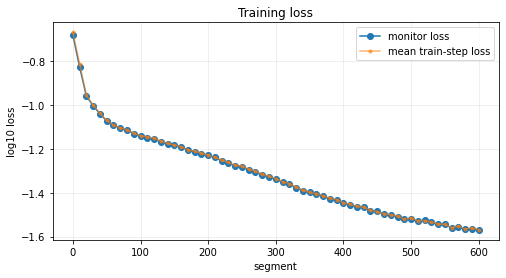

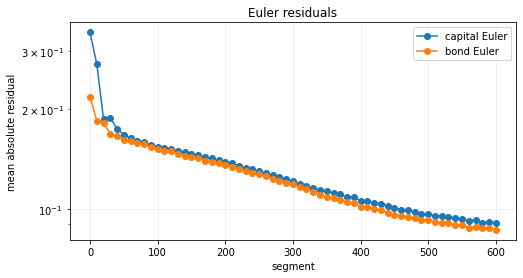

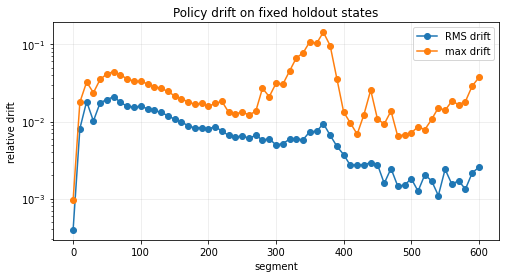

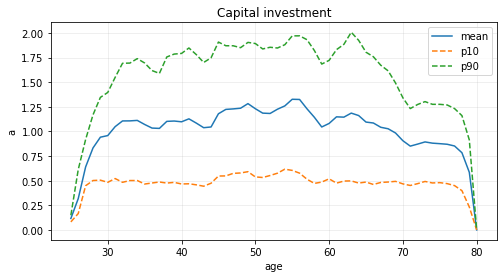

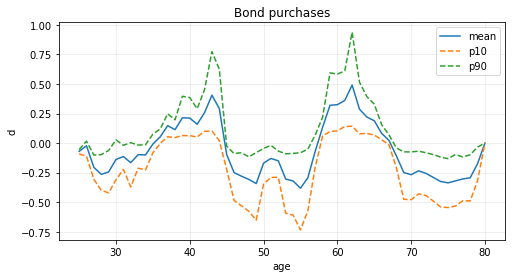

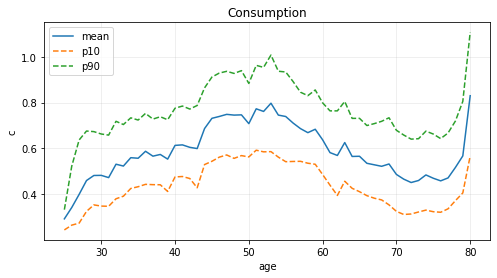

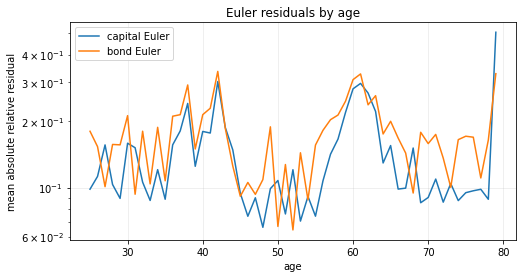

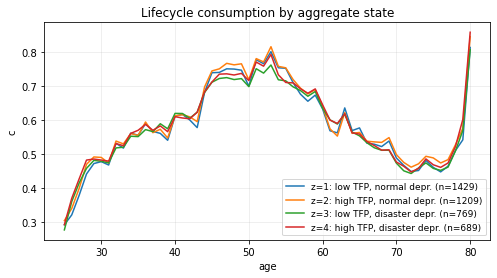

Mean consumption by state, highest first: z=2 (0.5926), z=4 (0.5877), z=1 (0.5819), z=3 (0.5793)


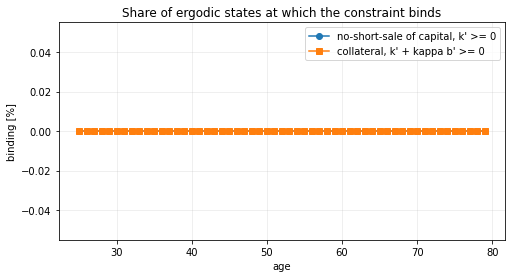

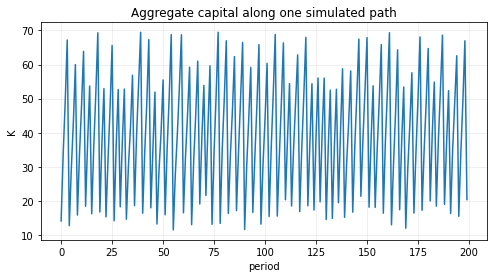

In [12]:
# ============================================================
# Simple plots
# ============================================================
if len(history["segment"]) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], np.log10(np.maximum(history["loss"], 1e-30)), marker="o", label="monitor loss")
    ax.plot(history["segment"], np.log10(np.maximum(history["train_loss"], 1e-30)), marker=".", alpha=0.6, label="mean train-step loss")
    ax.set_xlabel("segment")
    ax.set_ylabel("log10 loss")
    ax.set_title("Training loss")
    ax.grid(alpha=0.25)
    ax.legend()
    savefig(fig, "olg56_loss.pdf")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["mean_abs_euler_capital"], marker="o", label="capital Euler")
    ax.plot(history["segment"], history["mean_abs_euler_bond"], marker="o", label="bond Euler")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("mean absolute residual")
    ax.set_title("Euler residuals")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["policy_drift_rms"], marker="o", label="RMS drift")
    ax.plot(history["segment"], history["policy_drift_max"], marker="o", label="max drift")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("relative drift")
    ax.set_title("Policy drift on fixed holdout states")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def lifecycle_statistics(X, model):
    loss, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    a = comp["a"].numpy()
    d = comp["d"].numpy()
    c = comp["c"].numpy()
    a_all = np.concatenate([a, np.zeros((a.shape[0], 1), dtype=np.float32)], axis=1)
    d_all = np.concatenate([d, np.zeros((d.shape[0], 1), dtype=np.float32)], axis=1)
    return a_all, d_all, c


def plot_lifecycle_bands(X, model, max_states=4096):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 5151).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    a_all, d_all, c = lifecycle_statistics(X, model)
    for label, values, ylab in [
        ("Capital investment", a_all, "a"),
        ("Bond purchases", d_all, "d"),
        ("Consumption", c, "c"),
    ]:
        mean = np.mean(values, axis=0)
        p10 = np.quantile(values, 0.10, axis=0)
        p90 = np.quantile(values, 0.90, axis=0)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(AGES, mean, label="mean")
        ax.plot(AGES, p10, linestyle="--", label="p10")
        ax.plot(AGES, p90, linestyle="--", label="p90")
        ax.set_title(label)
        ax.set_xlabel("age")
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.25)
        ax.legend()
        savefig(fig, f"olg56_lifecycle_{ylab}.pdf")
        plt.show()


def plot_residuals_by_age(X, model, max_states=4096):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 6161).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    _, comp = compute_residuals(tf.constant(X), model)
    e_cap = np.abs(comp["euler_capital"].numpy())
    e_bond = np.abs(comp["euler_bond"].numpy())
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(AGES[:-1], np.mean(e_cap, axis=0), label="capital Euler")
    ax.plot(AGES[:-1], np.mean(e_bond, axis=0), label="bond Euler")
    ax.set_yscale("log")
    ax.set_xlabel("age")
    ax.set_ylabel("mean absolute relative residual")
    ax.set_title("Euler residuals by age")
    ax.grid(alpha=0.25)
    ax.legend()
    savefig(fig, "olg56_residuals_by_age.pdf")
    plt.show()


def plot_consumption_by_shock(X, model, max_states=8192):
    """Mean lifecycle consumption conditional on the aggregate state z."""
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 8181).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    _, _, c = lifecycle_statistics(X, model)
    z = X[:, 0].astype(int)
    labels = ["z=1: low TFP, normal depr.", "z=2: high TFP, normal depr.",
              "z=3: low TFP, disaster depr.", "z=4: high TFP, disaster depr."]
    fig, ax = plt.subplots(figsize=(8, 4))
    for s in range(NUM_SHOCKS):
        if np.any(z == s):
            ax.plot(AGES, c[z == s].mean(axis=0), label=f"{labels[s]} (n={int(np.sum(z == s))})")
    ax.set_title("Lifecycle consumption by aggregate state")
    ax.set_xlabel("age")
    ax.set_ylabel("c")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
    savefig(fig, "olg56_lifecycle_consumption_by_shock.pdf")
    plt.show()
    # print the ranking so the slides can quote it rather than guess it
    means = [c[z == s].mean() if np.any(z == s) else np.nan for s in range(NUM_SHOCKS)]
    order = np.argsort(means)[::-1]
    print("Mean consumption by state, highest first: " + ", ".join(f"z={s + 1} ({means[s]:.4f})" for s in order))


def plot_binding_by_age(bind_k, bind_q):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(AGES[:-1], 100 * bind_k, marker="o", label="no-short-sale of capital, k' >= 0")
    ax.plot(AGES[:-1], 100 * bind_q, marker="s", label="collateral, k' + kappa b' >= 0")
    ax.set_title("Share of ergodic states at which the constraint binds")
    ax.set_xlabel("age")
    ax.set_ylabel("binding [%]")
    ax.grid(alpha=0.25)
    ax.legend()
    savefig(fig, "olg56_binding_by_age.pdf")
    plt.show()


plot_lifecycle_bands(X_eval_sim, model)
plot_residuals_by_age(X_eval_sim, model)
plot_consumption_by_shock(X_eval_sim, model)
plot_binding_by_age(bind_k, bind_q)

# One illustrative simulated path.
path_one, _, _ = simulate_path(sample_feasible_initial_states(1, seed_offset=9999), model, 200, return_time_major=True)
K_path = path_one[:, 0, 1:1 + N_AGES].sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_path)
ax.set_title("Aggregate capital along one simulated path")
ax.set_xlabel("period")
ax.set_ylabel("K")
ax.grid(alpha=0.25)
plt.show()


## How to use the notebook

For a quick check, keep `RUN_MODE = "smoke"`. For a classroom run, use `RUN_MODE = "teaching"`.
For a paper-scale run, use `RUN_MODE = "production"`; this switches to 1000 hidden units and a long two-stage schedule. The production preset is intended for a GPU or distributed run.

The key point is the data-generation mode. In the exogenous notebook, every segment is an independent feasible state cloud. In the simulation notebook, each segment is generated by the current policy and the terminal states are used to start the next segment. In both cases, the diagnostics evaluate residuals on both exogenous and simulated out-of-sample clouds.
